<a href="https://colab.research.google.com/github/GUEST72/CSC311-Machine-Learning-projects/blob/main/assignment_3%20%20/%20Gaussian_Discriminant_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from scipy import stats
from warnings import filterwarnings
filterwarnings("ignore")

from scipy.stats import skew, kurtosis, jarque_bera, normaltest, zscore, multivariate_normal

#Data Loading & Preprocessing
## **Why merge the classes?**

The original Wine Quality dataset is imbalanced: most samples are rated 5–6, while very few are rated 3, 4, 8, or 9. This makes it hard for models to learn minority classes.

We merged the scores into three groups:

Low (3–4)

Medium (5–6)

High (7–9)

This reduces imbalance and gives a more practical interpretation (poor / average / good wine quality).

## **Handle Outliers (Z-score > 3)**
####**Empirical Rule (68-95-99.7 Rule): For a normal distribution:**

*   About 68% of the data falls within 1 standard deviation of the mean.
*  About 95% of the data falls within 2 standard deviations of the mean.
*  About 99.7% of the data falls within 3 standard deviations of the mean.







In [97]:

def load_and_preprocess(file_path):
    data = pd.read_csv(file_path, sep=";")
    data["quality_level"] = data["quality"].apply(lambda q: "Low" if q<=4 else "Medium" if q<=6 else "High")
    print("Quality distribution:\n", data["quality_level"].value_counts())
    X = data.drop(columns=["quality","quality_level"])
    y = data["quality_level"]
    return X, y

def load_and_preprocess_test(data):
    return data.drop(columns=["quality","quality_level"]), data["quality_level"]

def remove_outliers(X, y, z_thresh=3):
    mask = (np.abs(zscore(X)) < z_thresh).all(axis=1)
    return X[mask], y[mask]

def split_and_scale(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    scaler = StandardScaler().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test), y_train, y_val, y_test


# **Gaussian Assumption Check**
### Relationship between Skewness, Kurtosis, and the Gaussian Assumption

*   **Skewness:** Measures the asymmetry of the distribution.
    *   A Gaussian distribution is symmetrical and has a skewness of **zero**.
    *   Positive or negative skewness indicates asymmetry and deviation from the Gaussian shape.

*   **Kurtosis:** Measures the "tailedness" and peak shape of the distribution compared to the Gaussian distribution.
    *   A Gaussian distribution has an Excess Kurtosis of **zero**.
    *   Positive excess kurtosis indicates heavier tails and a sharper peak.
    *   Negative excess kurtosis indicates lighter tails and a flatter peak.

**Summary:**

When the skewness and excess kurtosis values are close to zero, it supports the assumption that the data follows a Gaussian distribution. This check is important for models that assume a Gaussian distribution for the data.

In [98]:
def check_gaussian(X, top_n=6):
    results = []
    for col in X.columns:
        vals = X[col].values
        s, k = skew(vals), kurtosis(vals)
        jb_p, da_p = jarque_bera(vals)[1], normaltest(vals)[1]
        results.append([col, s, k, abs(s)+abs(k), jb_p, da_p])

    df = pd.DataFrame(results, columns=["feature","skew","kurtosis","score","JB_p","DA_p"])
    print(df.round(3))
    selected = df.sort_values("score").head(top_n)["feature"].tolist()
    print("\nSelected features:", selected)
    plot_gaussian_assumptions(X,selected)
    return selected


def plot_gaussian_assumptions(X,selected):

    # Plot histograms and fitted Gaussian distributions
    fig, axes = plt.subplots(nrows=(len(selected) + 1) // 2, ncols=2, figsize=(12, 6))
    axes = axes.flatten()

    for i, col in enumerate(selected):
        vals = X[col].values
        mu, std = vals.mean(), vals.std()
        # Calculate appropriate x limits based on the data range and standard deviation
        xmin, xmax = vals.min() - std, vals.max() + std
        x = np.linspace(xmin, xmax, 100)
        p = stats.norm.pdf(x, mu, std)

        axes[i].hist(vals, bins=20, density=True, alpha=0.6, color='b')
        axes[i].plot(x, p, 'k', linewidth=2)
        axes[i].set_title(col)

    plt.tight_layout()
    plt.suptitle("Gaussian Assumption Check with Fitted Distributions", y=1.02)
    plt.show()

In [99]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score

class GaussianDiscriminantAnalysis:
    def __init__(self, shared_covariance=True, regularization=1e-6):

        self.shared_covariance = shared_covariance
        self.regularization = regularization

        # Initialize storage for class information
        self.classes_, self.priors_, self.means_, self.covariances_ = None, {}, {}, {}

    def fit(self, X, y):
        # Convert input to numpy arrays
        X, y = np.array(X), np.array(y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        # Compute class priors and class means
        for k in self.classes_:
            X_k = X[y == k]
            self.priors_[k] = len(X_k) / n_samples
            self.means_[k] = np.mean(X_k, axis=0)

        # Compute covariance matrices
        if self.shared_covariance:
            # Shared covariance matrix (LDA)
            # Weighted by class priors for fairness with imbalanced datasets
            cov = np.zeros((n_features, n_features))
            for k in self.classes_:
                X_k = X[y == k]
                diff = X_k - self.means_[k]
                cov += (self.priors_[k] * (diff.T @ diff) / len(X_k))
            # Add regularization to diagonal for numerical stability
            cov += np.eye(n_features) * self.regularization
            # Assign the same covariance matrix to each class
            for k in self.classes_:
                self.covariances_[k] = cov
        else:
            # Class-specific covariance matrices (QDA)
            for k in self.classes_:
                X_k = X[y == k]
                cov = np.cov(X_k.T, bias=False)  # unbiased sample covariance
                # Add regularization
                cov += np.eye(n_features) * self.regularization
                self.covariances_[k] = cov

        return self

    def _log_likelihood(self, X, k):
        # Log of the Gaussian PDF for class k
        return multivariate_normal.logpdf(
            X, mean=self.means_[k], cov=self.covariances_[k], allow_singular=False
        )

    def predict_proba(self, X):
        X = np.array(X)

        # Calculate log posterior for each class
        # log(P(k|X)) = log(P(X|k)) + log(P(k)) + constant
        log_post = np.array([
            self._log_likelihood(X, k) + np.log(self.priors_[k])
            for k in self.classes_
        ]).T

        # Stabilize log probabilities before exponentiation
        log_post -= log_post.max(axis=1, keepdims=True)

        # Convert log probabilities to actual probabilities
        probs = np.exp(log_post)

        # Normalize probabilities so that they sum to 1
        return probs / probs.sum(axis=1, keepdims=True)

    def predict(self, X):
        # Predict class with maximum posterior probability
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

    def score(self, X, y):
        # Compute classification accuracy
        return accuracy_score(y, self.predict(X))


In [100]:
# Analyze the effect of covariance type on model performance
def analyze_covariance(X_train, X_val, y_train, y_val):

    # Train LDA with shared covariance
    lda = GaussianDiscriminantAnalysis(True).fit(X_train, y_train)
    # Train QDA with unshared covariance
    qda = GaussianDiscriminantAnalysis(False).fit(X_train, y_train)

    # Print validation accuracy for both models
    print("LDA val acc:", lda.score(X_val, y_val))
    print("QDA val acc:", qda.score(X_val, y_val))
    return lda, qda


In [101]:

# Analyze the correlation between features
def analyze_correlation(X, features):

    # Create a DataFrame from the features and compute the correlation matrix
    corr = pd.DataFrame(X, columns=features).corr()
    # Visualize the correlation matrix using a heatmap
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
    plt.show()


In [102]:
def analyze_dimensionality(X_train, X_val, y_train, y_val, selected_indices):
    scores = {"lda":[], "qda":[]}
    max_features = len(selected_indices)

    # Analyze all possible numbers of features from 2 to max_features
    for n in range(2, max_features + 1):
        # Use the top n most Gaussian features
        current_indices = selected_indices[:n]

        lda = GaussianDiscriminantAnalysis(True).fit(X_train[:, current_indices], y_train)
        qda = GaussianDiscriminantAnalysis(False).fit(X_train[:, current_indices], y_train)

        scores["lda"].append(lda.score(X_val[:, current_indices], y_val))
        scores["qda"].append(qda.score(X_val[:, current_indices], y_val))

        print(f"Top {n} Gaussian Features: LDA={scores['lda'][-1]:.3f}, QDA={scores['qda'][-1]:.3f}")

    # Plotting code
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_features + 1), scores["lda"], label="LDA", marker='o', linewidth=2)
    plt.plot(range(2, max_features + 1), scores["qda"], label="QDA", marker='s', linewidth=2)
    plt.xlabel("Number of Best Gaussian Features")
    plt.ylabel("Validation Accuracy")
    plt.title("Performance vs Number of Best Gaussian Features")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(2, max_features + 1))
    plt.show()

    return scores

In [103]:

# Compare our GDA implementation with scikit-learn's LDA and QDA
def compare_with_sklearn(X_train, X_val, X_test, y_train, y_val, y_test):

    # Define the models to compare
    models = {
        "Our LDA": GaussianDiscriminantAnalysis(True),
        "Our QDA": GaussianDiscriminantAnalysis(False),
        "Sklearn LDA": LinearDiscriminantAnalysis(),
        "Sklearn QDA": QuadraticDiscriminantAnalysis()
    }
    # Iterate through the models and evaluate their performance
    for name, model in models.items():
        model.fit(X_train, y_train)
        # Print the performance metrics for each model
        print(f"{name}: Train={model.score(X_train,y_train):.3f}, Val={model.score(X_val,y_val):.3f}, Test={model.score(X_test,y_test):.3f}")

Quality distribution:
 quality_level
Medium    3655
High      1060
Low        183
Name: count, dtype: int64
                 feature   skew  kurtosis  score  JB_p  DA_p
0          fixed acidity  0.302     0.188  0.490   0.0   0.0
1       volatile acidity  0.748     0.636  1.384   0.0   0.0
2            citric acid  0.431     1.113  1.544   0.0   0.0
3         residual sugar  0.708    -0.572  1.279   0.0   0.0
4              chlorides  1.050     3.427  4.477   0.0   0.0
5    free sulfur dioxide  0.362    -0.281  0.643   0.0   0.0
6   total sulfur dioxide  0.270    -0.290  0.560   0.0   0.0
7                density  0.261    -0.799  1.059   0.0   0.0
8                     pH  0.278    -0.048  0.326   0.0   0.0
9              sulphates  0.647     0.291  0.938   0.0   0.0
10               alcohol  0.443    -0.749  1.192   0.0   0.0

Selected features: ['pH', 'fixed acidity', 'total sulfur dioxide', 'free sulfur dioxide', 'sulphates', 'density']


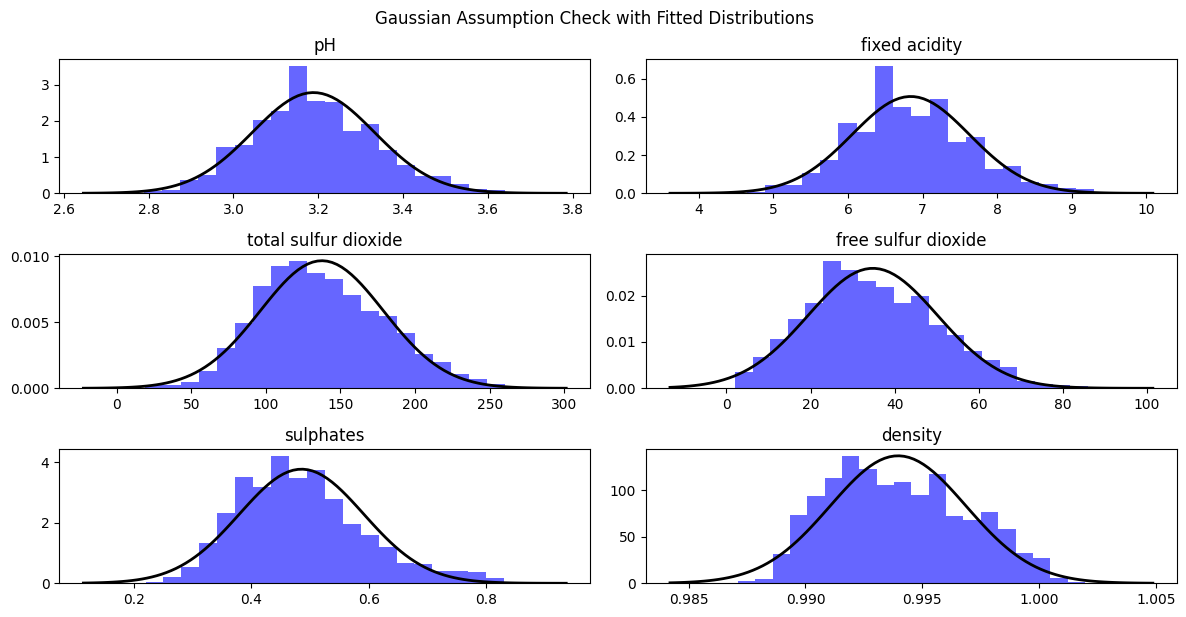

LDA val acc: 0.7451851851851852
QDA val acc: 0.7422222222222222


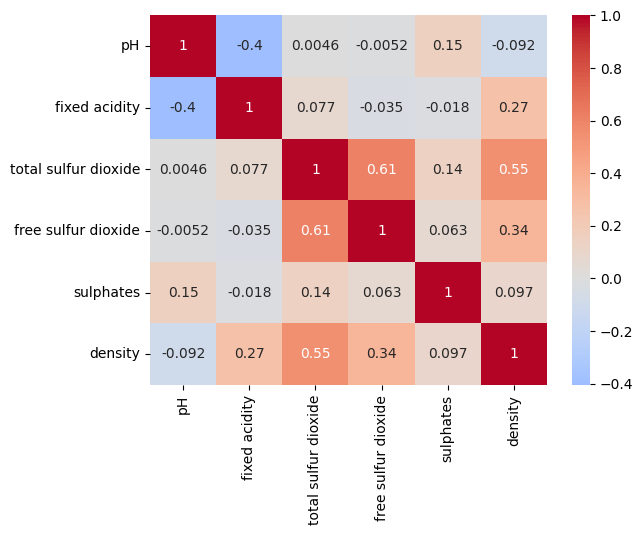

Top 2 Gaussian Features: LDA=0.744, QDA=0.745
Top 3 Gaussian Features: LDA=0.744, QDA=0.738
Top 4 Gaussian Features: LDA=0.744, QDA=0.741
Top 5 Gaussian Features: LDA=0.744, QDA=0.747
Top 6 Gaussian Features: LDA=0.745, QDA=0.742


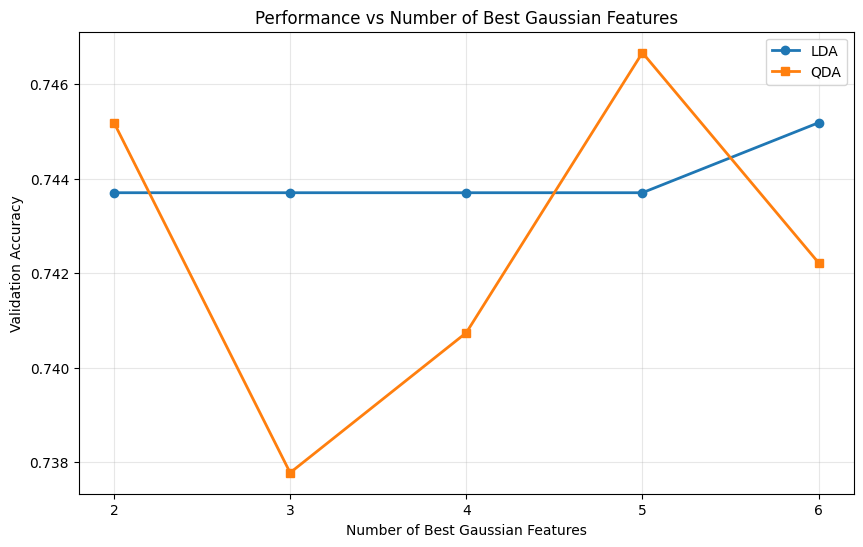

Our LDA: Train=0.751, Val=0.745, Test=0.754
Our QDA: Train=0.750, Val=0.742, Test=0.765
Sklearn LDA: Train=0.750, Val=0.745, Test=0.754
Sklearn QDA: Train=0.750, Val=0.742, Test=0.765


In [104]:
X, y = load_and_preprocess("/content/drive/MyDrive/Datasets/winequality-white.csv")

X_no_out, y_no_out = remove_outliers(X, y)

# After getting the selected features from check_gaussian()
selected = check_gaussian(X_no_out)  # Returns feature names like ['alcohol', 'volatile acidity', ...]

# Get the column indices of the selected features
feature_columns = list(X_no_out.columns)
selected_indices = [feature_columns.index(feat) for feat in selected]


X_train, X_val, X_test, y_train, y_val, y_test = split_and_scale(X_no_out, y_no_out)

# Use the actual selected features, not just the first n features
X_train_selected = X_train[:, selected_indices]
X_val_selected = X_val[:, selected_indices]
X_test_selected = X_test[:, selected_indices]


# Call with the actual selected indices
lda, qda = analyze_covariance(X_train_selected, X_val_selected, y_train, y_val)
analyze_correlation(X_train_selected, selected)
analyze_dimensionality(X_train, X_val, y_train, y_val, selected_indices)
compare_with_sklearn(X_train_selected, X_val_selected, X_test_selected, y_train, y_val, y_test)


--- Model Evaluation on Test Set ---

Evaluating Our LDA:
Accuracy: 0.754
Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.06      0.11       153
         Low       0.00      0.00      0.00        20
      Medium       0.75      1.00      0.86       503

    accuracy                           0.75       676
   macro avg       0.52      0.35      0.32       676
weighted avg       0.75      0.75      0.66       676



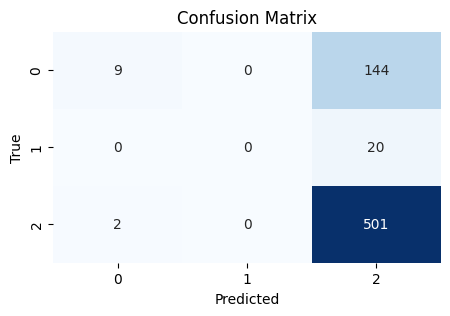


Evaluating Our QDA:
Accuracy: 0.765
Classification Report:
              precision    recall  f1-score   support

        High       0.60      0.29      0.39       153
         Low       0.33      0.05      0.09        20
      Medium       0.79      0.94      0.86       503

    accuracy                           0.76       676
   macro avg       0.57      0.43      0.44       676
weighted avg       0.73      0.76      0.73       676



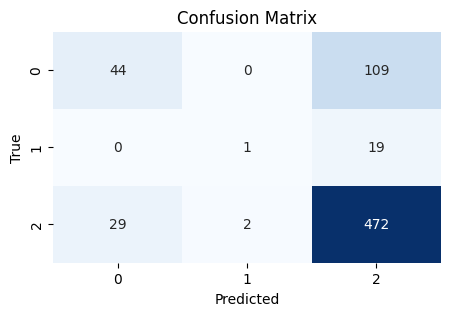

In [105]:
# Evaluate the performance of the trained models on the test set
print("\n--- Model Evaluation on Test Set ---")

models_to_evaluate = {
    "Our LDA": lda, # Assuming lda is the trained LDA model from yN1gu2_hnoCc
    "Our QDA": qda  # Assuming qda is the trained QDA model from yN1gu2_hnoCc
}

for name, model in models_to_evaluate.items():
    print(f"\nEvaluating {name}:")

    # Make predictions on the test set
    y_pred = model.predict(X_test_selected)

    # Calculate and print evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.3f}")
    print("Classification Report:")
    print(report)
    plt.figure(figsize=(5,3))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
